In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from sklearn.datasets import make_regression



Линейная регрессия (Linear regression) — один из простейший алгоритмов машинного обучения, описывающий зависимость целевой переменной от признака в виде линейной функции $y=kx$. В данном случае была представлена простая или парная линейная регрессия, а уравнение вида$f_{w, b}(x) = \sum_{i=0}^{n} w_i x_i + b = w \cdot x + b$ называется множественной линейной регрессией, где $b$ — смещение модели, $w$ — вектор её весов, а $x$ — вектор признаков одного обучающего образца.

Исходя из теоремы [Гаусса-Маркова](https://ru.wikipedia.org/wiki/%D0%A2%D0%B5%D0%BE%D1%80%D0%B5%D0%BC%D0%B0_%D0%93%D0%B0%D1%83%D1%81%D1%81%D0%B0_%E2%80%94_%D0%9C%D0%B0%D1%80%D0%BA%D0%BE%D0%B2%D0%B0), метод наименьших квадратов является наиболее оптимальной оценкой параметров модели среди всех линейных и несмещённых оценок за счёт меньшей дисперсии.

$$
\begin{align*}
J(w, X, y) &= \frac{1}{2n} \sum\limits_{i = 1}^{n} (w^T x_i - y_i)^2 = \frac{1}{2n} \|X w - y\|^{2} = \frac{1}{2n} (X w - y)^T (X w - y) = \\
&= \frac{1}{2n} ((X w)^T X w - (X w)^T y - y^T X w + y^T y) \quad |(X w)^T y = y^T X w| = \\
&= \frac{1}{2n} (w^T X^T X w - 2 y^T X w + y^T y) \\[10pt]
\frac{\partial J}{\partial w} &= 0 \quad \Rightarrow \quad \frac{1}{2n} (2X^T X w - 2X^T y) = 0 \quad \Rightarrow \quad X^T X w = X^T y \quad \Rightarrow \\
&\Rightarrow w = (X^T X)^{-1} X^T y
\end{align*}
$$
\begin{align*} - хорошо подходит для многострочных формул


2 основных способа обучения линейной регрессии:
1) Прямое уравнение в аналитическом виде: $w=(X^TX)^{-1}X^Ty$. Главный недостаток данного способа заключается в высокой вычислительной сложности при большом количестве признаков.
2) Итеративная оптимизация с постепенным снижением ошибки модели на основе градиентного спуска и его разновидностей. Алгоритм:
	-  изначально устанавливаются нулевые значения для весов, смещения и их градиентов;
	    
	-  на основе установленных значений делается прогноз;
	    
	- на основе полученного прогноза пересчитываются значения весов и смещения, а также снижение их градиентов (разность значений на текущей и предыдущей итерациях);
	    
	- шаги 2-3 повторяются до тех пор, пока снижение градиентов не станет меньше заранее установленного порогового значения;
	    
	-  итоговым прогнозом будет линейная комбинация полученных весов + смещение и признаков на тестовой выборке.
	Формулы: Градиенты смещения и весов:

Формула Градиентного спуска:
$$
\begin{align*} 
\frac{\partial J(\Theta)}{\partial b}  &= \frac{1}{n} \sum\limits_{i = 1}^{n} (f_{w ,b}(x_i) - y_i) \\ \frac{\partial J(\Theta)}{\partial w}  &= \frac{1}{n} \sum\limits_{i = 1}^{n} (f_{w ,b}(x_i) - y_i) x_i \\ 
\end{align*}
$$

Обновление:
$b_j=b_{j-1}-\alpha \frac{\partial J(\Theta)}{\partial b_j}$
$w_j=w_{j-1}-\alpha \frac{\partial J(\Theta)}{\partial w_j}$
$\alpha$-скорость обучения; j - текущая итерация; $\Theta$ - матрица параметров


In [14]:
import numpy as np

class MatrixLinearRegression:
    
    def fit(self, X, y):
        X = np.insert(X, 0, 1, axis=1)  
        XT_X_inv = np.linalg.inv(X.T @ X)  
        weights = np.linalg.multi_dot([XT_X_inv, X.T, y])  
        self.bias = weights[0]  
        self.weights = weights[1:]  
    
    def predict(self, X_test):
        return X_test @ self.weights + self.bias  

	
class GDLinearRegression:
    def __init__(self, learning_rate=0.01, tolerance=1e-8):
        self.learning_rate = learning_rate
        self.tolerance = tolerance
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.bias = 0
        self.weights = np.zeros(n_features)
        previous_db = 0
        previous_dw = np.zeros(n_features)
        
        while True:
            y_pred = X @ self.weights + self.bias
            db = (1 / n_samples) * np.sum(y_pred - y)
            dw = (1 / n_samples) * (X.T @ (y_pred - y))
            
            self.bias -= self.learning_rate * db
            self.weights -= self.learning_rate * dw
            
            abs_db_reduction = abs(db - previous_db)
            abs_dw_reduction = abs(dw - previous_dw)
            
            if abs_db_reduction < self.tolerance and np.all(abs_dw_reduction < self.tolerance):
                break
            
            previous_db = db
            previous_dw = dw
    
    def predict(self, X_test):
        return X_test @ self.weights + self.bias


# Test
if __name__ == "__main__":
    np.random.randint(42)
    X = np.random.rand(100, 1) * 10
    y = 3 * X.squeeze() + 5 + np.random.randn(100) * 2
    
    model = GDLinearRegression(learning_rate=0.01, tolerance=1e-8)
    model.fit(X, y)
    
    print(f"Weight after GDLinearRegression: {model.weights[0]:.4f}")
    print(f"Bias after GDLinearRegression: {model.bias:.4f}")
    model1 = MatrixLinearRegression()
    model1.fit(X,y)
    print(f"Weight after MatrixLinear: {model1.weights[0]:.4f}")
    print(f"Bias after MatrixLinear: {model1.bias:.4f}")
    


Weight after GDLinearRegression: 3.0358
Bias after GDLinearRegression: 4.7294
Weight after MatrixLinear: 3.0358
Bias after MatrixLinear: 4.7295


Эти способы реализованы в библиотеки sklearn: LinearRegression(), SGDRegressor().
Плюсы и минусы обоих методов:

# АНАЛИТИЧЕСКИЙ МЕТОД (Normal Equation):
   Плюсы:
   - Точное решение за один шаг
   - Не нужно подбирать learning rate
   - Не нужно беспокоиться о сходимости
   
   Минусы:
   - Вычислительная сложность O(n³) для n признаков
   - Плохо работает при n > 10000
   - Требует обращения матрицы

# ГРАДИЕНТНЫЙ СПУСК:
   Плюсы:
   - Хорошо масштабируется на большие данные
   - Модель может обучаться на данных, которые поступают постепенно, а не все сразу
   - Можно использовать раннюю остановку. Прекращение обучения, когда ошибка на валидационной выборке перестаёт улучшаться
   
   Минусы:
   - Нужно подбирать learning rate
   - Может застрять в локальном минимуме
   - Требует стандартизации данных (StandardScaler)

# ВЫБОР МЕТОДА:
   - Мало признаков (< 1000) - аналитический метод
   - Много признаков или данных - градиентный спуск
   - Важна точность - аналитический метод
   - Важна скорость обучения - градиентный спуск 

Почему градиентный спуск требует стандартизации данных ?
$$
J(w_1, w_2) = \frac{1}{2n} \sum (w_1 x_1 + w_2 x_2 + b - y)^2
$$

$$
\frac{\partial J}{\partial w_1} = \frac{1}{n} \sum (f(x) - y) \cdot x_1
$$

$$
\frac{\partial J}{\partial w_2} = \frac{1}{n} \sum (f(x) - y) \cdot x_2
$$

Проблема состоит в том, что если x2 в 1000 раз > x2, то градиент w2 будет в 1000 раз больше

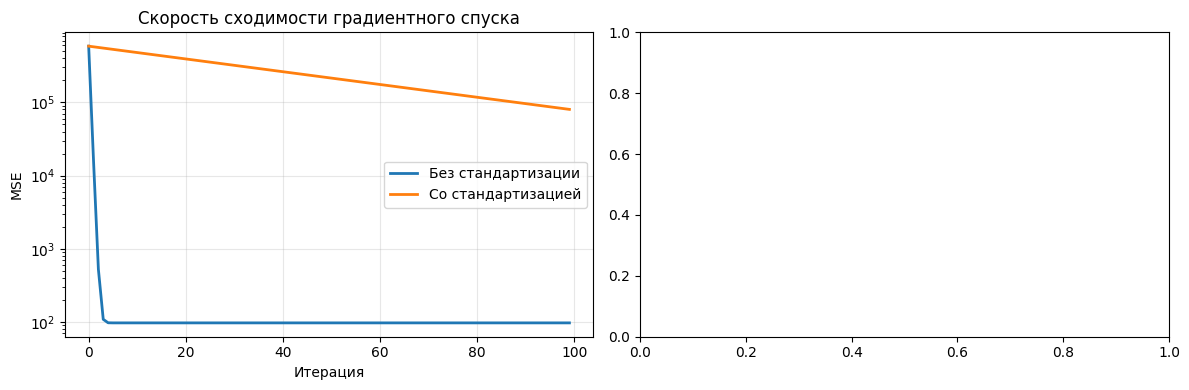

Без стандартизации: MSE = 97.10 (за 100 итераций)
Со стандартизацией:  MSE = 80267.83 (за 100 итераций)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Создаём данные с разным масштабом признаков
np.random.seed(42)
n_samples = 100

# Признак 1: маленький масштаб (0-1)
X1 = np.random.rand(n_samples) * 1

# Признак 2: большой масштаб (1000-2000)
X2 = np.random.rand(n_samples) * 1000 + 1000

# Целевая переменная
y = 3 * X1 + 0.5 * X2 + np.random.randn(n_samples) * 10

X = np.column_stack([X1, X2])

# Очищаем данные от inf/NaN
X = np.nan_to_num(X, nan=0.0, posinf=1e10, neginf=-1e10)
y = np.nan_to_num(y, nan=0.0, posinf=1e10, neginf=-1e10)

def train_and_track(X, y, learning_rate=0.000001, n_iterations=100):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    bias = 0
    history = []
    
    for i in range(n_iterations):
        y_pred = X @ weights + bias
        dw = (1/n_samples) * X.T @ (y_pred - y)
        db = (1/n_samples) * np.sum(y_pred - y)
        
        # Проверка на бесконечность
        if np.any(np.abs(dw) > 1e10) or np.abs(db) > 1e10:
            print(f"Градиент взорвался на итерации {i}")
            break
        
        weights -= learning_rate * dw
        bias -= learning_rate * db
        
        mse = np.mean((y_pred - y) ** 2)
        history.append(mse)
        
        # Ранняя остановка при росте ошибки
        if len(history) > 2 and history[-1] > history[-2] * 10:
            print(f" Ошибка резко выросла на итерации {i}")
            break
    
    return history, weights, bias

history_raw, weights_raw, bias_raw = train_and_track(X, y, learning_rate=0.0000005)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
history_scaled, weights_scaled, bias_scaled = train_and_track(X_scaled, y, learning_rate=0.01)

# Визуализация (только если история не пустая)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if len(history_raw) > 0 and len(history_scaled) > 0:
    axes[0].plot(history_raw, label='Без стандартизации', linewidth=2)
    axes[0].plot(history_scaled, label='Со стандартизацией', linewidth=2)
    axes[0].set_xlabel('Итерация')
    axes[0].set_ylabel('MSE')
    axes[0].set_title('Скорость сходимости градиентного спуска')
    axes[0].legend()
    axes[0].set_yscale('log')
    axes[0].grid(True, alpha=0.3)



plt.tight_layout()
plt.show()


if len(history_raw) > 0:
    print(f"Без стандартизации: MSE = {history_raw[-1]:.2f} (за {len(history_raw)} итераций)")
else:
    print("Без стандартизации: не сошлось")
    
if len(history_scaled) > 0:
    print(f"Со стандартизацией:  MSE = {history_scaled[-1]:.2f} (за {len(history_scaled)} итераций)")
else:
    print("Со стандартизацией: не сошлось")

### Полиномиальная регрессия

Линейную регрессию также можно применять к данным с нелинейной зависимостью, добавив степени каждого признака в виде новых признаков с последующим обучением на полученном датасете. Такой подход позволяет улавливать линейные связи в многомерном пространстве признаков и называется **полиномиальной регрессией**, а для преобразования признаков в полином степени _n_ в scikit-learn имеется класс PolynomialFeatures, который кроме степеней каждого признака ещё добавляет их комбинации до заданной степени.

**Как понять, что данные не линейны ?**

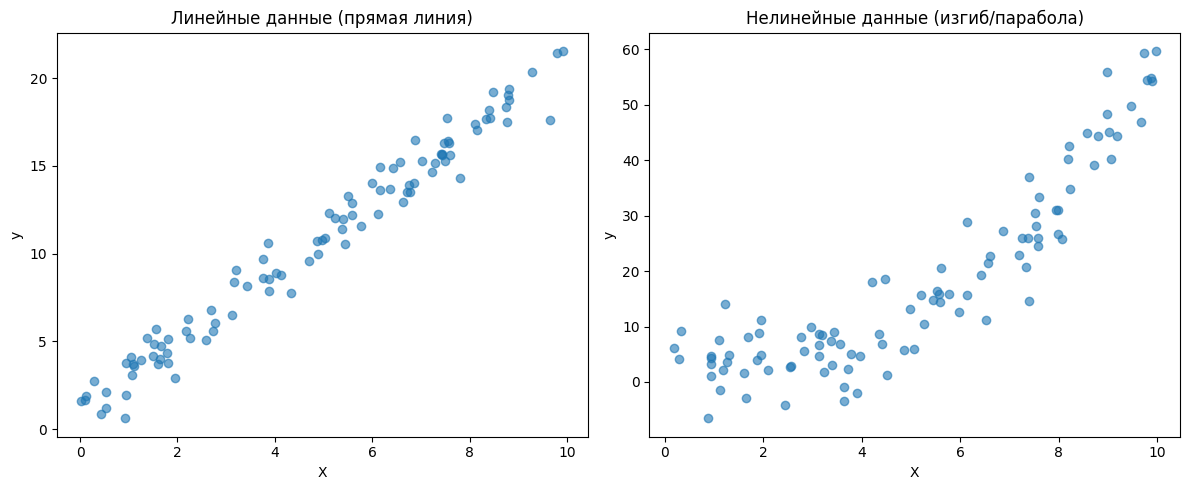

In [26]:
import numpy as np
import matplotlib.pyplot as plt
np.random.randint(42)

# Линейные данные
X_linear = np.random.rand(100, 1) * 10
y_linear = 2 * X_linear.squeeze() + 1 + np.random.randn(100) * 1

# Нелинейные данные (квадратичные)

X_nonlinear = np.random.rand(100, 1) * 10
y_nonlinear = X_nonlinear.squeeze()**2 - 5 * X_nonlinear.squeeze() + 10 + np.random.randn(100) * 5

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(X_linear, y_linear, alpha=0.6)
ax1.set_title("Линейные данные (прямая линия)")
ax1.set_xlabel("X")
ax1.set_ylabel("y")

ax2.scatter(X_nonlinear, y_nonlinear, alpha=0.6)
ax2.set_title("Нелинейные данные (изгиб/парабола)")
ax2.set_xlabel("X")
ax2.set_ylabel("y") 

plt.tight_layout()
plt.show()


если использовать полином слишком высокой степени, то модель будет явно переобучена, а если низкой, то недообучена. Для решения данной проблемы необходимо использовать перебор нескольких полиномов для выбора оптимальной кривизны линии, описывающей взаимосвязь в данных наилучшим образом.


Линейная регрессия:
  R²: 0.7030
  MSE: 5.0013
  MAPE: 0.5638

Полиномиальная регрессия (degree=2):
  R²: 0.9248
  MSE: 1.2661
  MAPE: 0.2500


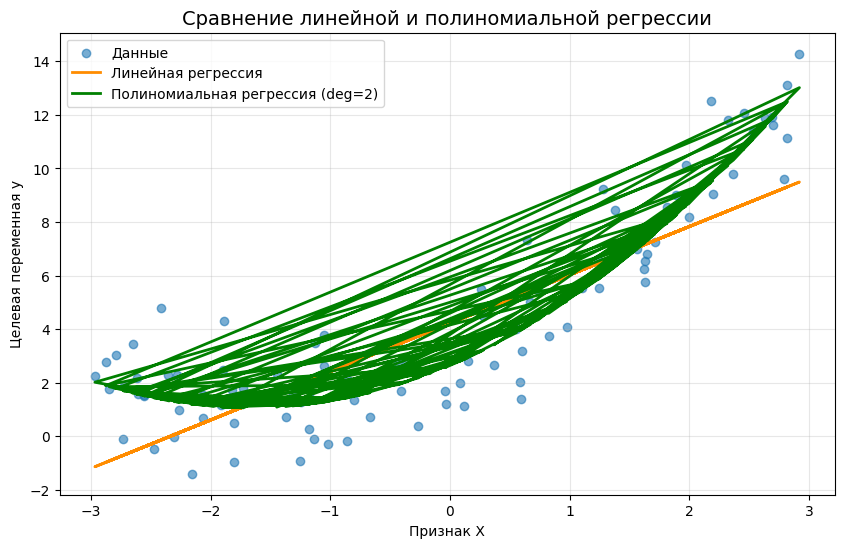

In [ ]:
# ПОЛИНОМИАЛЬНАЯ vs ЛИНЕЙНАЯ РЕГРЕССИЯ

# Генерируем НЕЛИНЕЙНЫЕ данные (парабола + шум)
np.random.seed(42)
n_samples = 100
X = np.random.uniform(-3, 3, n_samples).reshape(-1, 1)
y = 0.5 * X.squeeze()**2 + 2 * X.squeeze() + 3 + np.random.randn(n_samples) * 1.5

feature_name = "Признак X"
target_name = "Целевая переменная y"

# Разделяем данные
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Создаём полиномиальные признаки (degree=2)
# Степень 8 вызовет сильное переобучение
poly = PolynomialFeatures(degree=2, include_bias=True)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)
X_poly_all = poly.transform(X)

# Обучаем линейную регрессию
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_pred_lr_all = lr.predict(X)

# Обучаем полиномиальную регрессию
poly_lr = LinearRegression()
poly_lr.fit(X_poly_train, y_train)
y_pred_poly = poly_lr.predict(X_poly_test)
y_pred_poly_all = poly_lr.predict(X_poly_all)

# Метрики
lr_r2 = r2_score(y_test, y_pred_lr)
poly_r2 = r2_score(y_test, y_pred_poly)

lr_mse = mean_squared_error(y_test, y_pred_lr)
poly_mse = mean_squared_error(y_test, y_pred_poly)

lr_mape = mean_absolute_percentage_error(y_test, y_pred_lr)
poly_mape = mean_absolute_percentage_error(y_test, y_pred_poly)

print(f"\nЛинейная регрессия:")
print(f"  R²: {lr_r2:.4f}")
print(f"  MSE: {lr_mse:.4f}")
print(f"  MAPE: {lr_mape:.4f}")

print(f"\nПолиномиальная регрессия (degree=2):")
print(f"  R²: {poly_r2:.4f}")
print(f"  MSE: {poly_mse:.4f}")
print(f"  MAPE: {poly_mape:.4f}")

# Визуализация
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.6, label='Данные')
plt.plot(X, y_pred_lr_all, color='darkorange', linewidth=2, label='Линейная регрессия')
plt.plot(X, y_pred_poly_all, color='green', linewidth=2, label='Полиномиальная регрессия (deg=2)')
plt.title('Сравнение линейной и полиномиальной регрессии', fontsize=14)
plt.xlabel(feature_name)
plt.ylabel(target_name)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Регуляризация линейной регрессии (Ridge, Lasso, ElasticNet)
Если в полиномиальной регрессии регуляризация позволяет уменьшить кривизну линии через снижение количества полиномиальных степеней, то в случае с линейной регрессией регуляризация будет заключаться в изменении наклона линии путём ограничения весов модели, обменивая более высокое смещение на низкую дисперсию.

## Гребневая регрессия (Ridge regression) или регуляризация Тихонова 
применяется в случае мультиколлинеарности через добавление L2-регуляризации к функции потерь во время обучения и сильнее всего занижает веса для признаков с высокой корреляцией: их значения будут приближаться к нулю, но никогда его не достигнут. Лучше всего применять гребневую регрессию после стандартизации признаков.

$J += \alpha \sum \limits_{i=1}^{n} w_i^2$
## Лассо-регрессия (Lasso regression или Least Absolute Shrinkage & Selection Operator) 
обычно используется для отбора признаков через добавление L1-регуляризации к функции потерь во время обучения. Проще говоря, лассо-регрессия стремится уменьшить число параметров модели путем зануления весов для неинформативных и избыточных признаков, что на выходе даст разреженную модель (с небольшим числом ненулевых весов признаков).

$J += \alpha \sum \limits_{i=1}^{n} |w_i|$
## Эластичная сеть (ElasticNet) 
представляет собой комбинацию L1 и L2-регуляризаций через отношение их смеси r, что может принести особую пользу в ситуациях, когда в данных необходимо одновременно выполнять отбор признаков и бороться с мультиколлинеарностью. В Scikit-Learn для управления смесью Ridge и Lasso используется "l1_ratio".

$J = MSE(w) + r\alpha \sum \limits_{i=1}^{n} |w_i| + \frac{1 - r}{2} \alpha \sum \limits_{i=1}^{n} w_i^2$
Кроме того, в качестве регуляризации линейной регрессии ещё можно использовать раннюю остановку (early stopping), которая заключаются в прекращении обучения модели после определённого количества итераций или достижения заданного уровня ошибки на валидационной выборке.


Метрики на тестовой выборке:
------------------------------------------------------------
Модель               R²         MSE          MAPE      
------------------------------------------------------------
Linear Regression    0.9937     0.2528       0.2589    
Ridge (L2)           0.9943     0.2301       0.2504    
Lasso (L1)           0.9946     0.2180       0.2956    
ElasticNet           0.9940     0.2409       0.2416    
Сравнение коэффициентов моделей (первые 10 признаков):
Признак  True       Linear     Ridge      Lasso      ElasticNet  
------------------------------------------------------------
w0       3.00       2.514      2.474      2.454      2.360     
w1       1.50       1.739      1.710      1.726      1.632     
w2       0.00       0.014      0.101      0.002      0.241     
w3       0.00       0.110      0.097      0.013      0.065     
w4       2.00       2.825      2.712      2.821      2.479     
w5       0.00       0.145      0.192      0.010      0.231     
w6

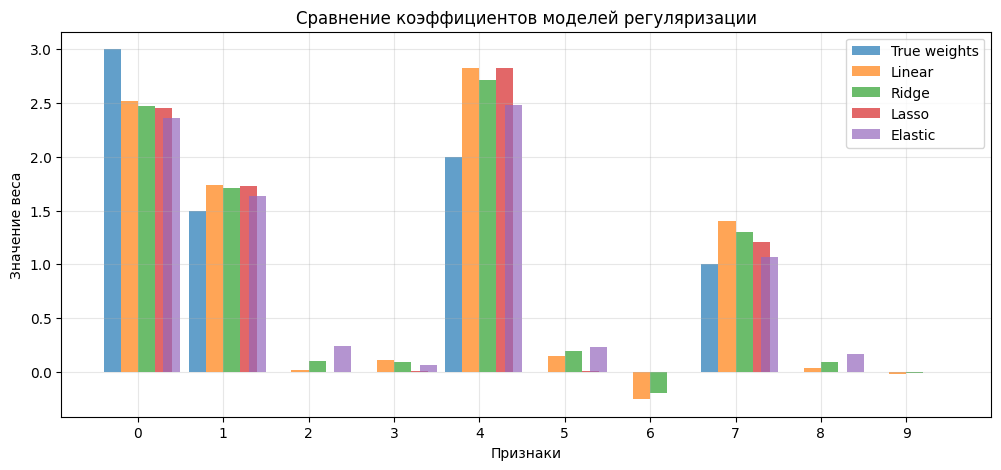


ЧАСТЬ 3: Визуализация на простых данных с шумом


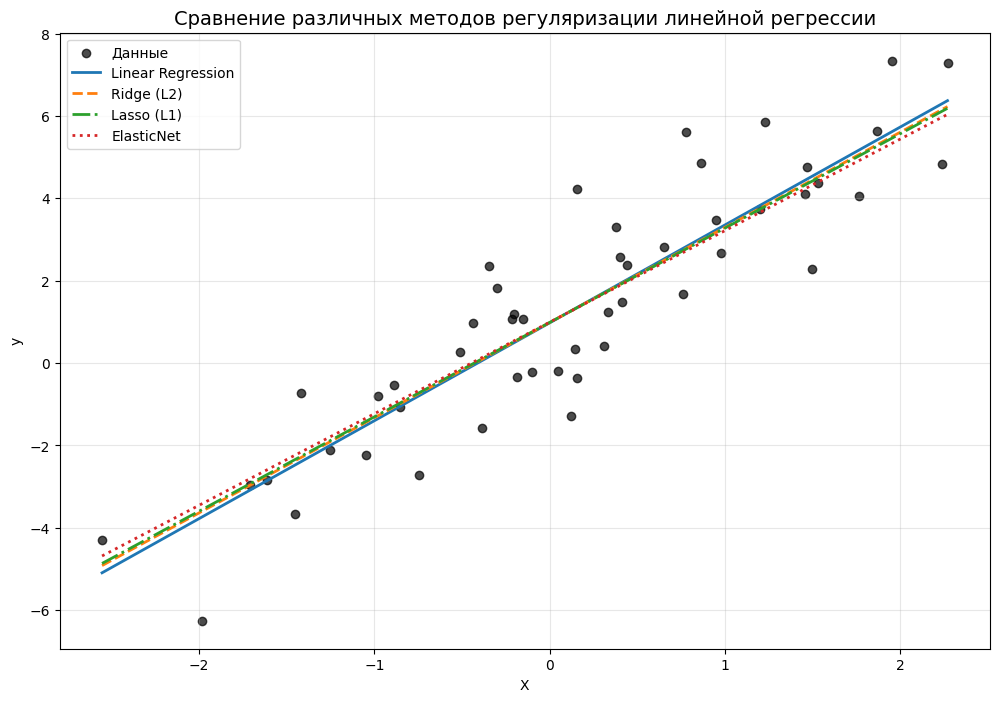

In [32]:
# РЕГУЛЯРИЗАЦИЯ LINEAR REGRESSION (Ridge, Lasso, ElasticNet)

np.random.seed(42)
n_samples_reg = 100
n_features_reg = 10  # 10 признаков

# Создаём коррелированные признаки (мультиколлинеарность)
X_reg = np.random.randn(n_samples_reg, n_features_reg)
# Добавляем корреляцию между признаками
for i in range(1, n_features_reg):
    X_reg[:, i] = X_reg[:, i] + 0.7 * X_reg[:, i-1]

# Генерируем целевую переменную с шумом
true_weights = np.array([3, 1.5, 0, 0, 2, 0, 0, 1, 0, 0])
y_reg = X_reg @ true_weights + np.random.randn(n_samples_reg) * 0.5

# Разделяем данные
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42
)

#Масштабируем данные для регуляризации
scaler = StandardScaler()
X_reg_train_scaled = scaler.fit_transform(X_reg_train)
X_reg_test_scaled = scaler.transform(X_reg_test)

# 1. Linear Regression
lr_reg = LinearRegression()
lr_reg.fit(X_reg_train_scaled, y_reg_train)
lr_pred = lr_reg.predict(X_reg_test_scaled)

# 2. Ridge Regression (L2)
ridge = Ridge(alpha=1.0)  # alpha - сила регуляризации
ridge.fit(X_reg_train_scaled, y_reg_train)
ridge_pred = ridge.predict(X_reg_test_scaled)

# 3. Lasso Regression (L1)
lasso = Lasso(alpha=0.1)  # Lasso чувствительнее к выбору alpha
lasso.fit(X_reg_train_scaled, y_reg_train)
lasso_pred = lasso.predict(X_reg_test_scaled)

# 4. ElasticNet (L1 + L2)
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)  # l1_ratio=0.5 - смесь 50/50
elastic.fit(X_reg_train_scaled, y_reg_train)
elastic_pred = elastic.predict(X_reg_test_scaled)

# Сравнение метрик
models = {
    'Linear Regression': lr_pred,
    'Ridge (L2)': ridge_pred,
    'Lasso (L1)': lasso_pred,
    'ElasticNet': elastic_pred
}

print("\nМетрики на тестовой выборке:")
print("-" * 60)
print(f"{'Модель':<20} {'R²':<10} {'MSE':<12} {'MAPE':<10}")
print("-" * 60)

for name, pred in models.items():
    r2 = r2_score(y_reg_test, pred)
    mse = mean_squared_error(y_reg_test, pred)
    mape = mean_absolute_percentage_error(y_reg_test, pred)
    print(f"{name:<20} {r2:<10.4f} {mse:<12.4f} {mape:<10.4f}")

# Сравнение весов моделей
print("Сравнение коэффициентов моделей (первые 10 признаков):")
print(f"{'Признак':<8} {'True':<10} {'Linear':<10} {'Ridge':<10} {'Lasso':<10} {'ElasticNet':<12}")
print("-" * 60)

for i in range(10):
    print(f"w{i:<7} {true_weights[i]:<10.2f} "
          f"{lr_reg.coef_[i]:<10.3f} "
          f"{ridge.coef_[i]:<10.3f} "
          f"{lasso.coef_[i]:<10.3f} "
          f"{elastic.coef_[i]:<10.3f}")

# Визуализация коэффициентов
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(10)
width = 0.2

ax.bar(x - 1.5*width, true_weights, width, label='True weights', alpha=0.7)
ax.bar(x - 0.5*width, lr_reg.coef_[:10], width, label='Linear', alpha=0.7)
ax.bar(x + 0.5*width, ridge.coef_[:10], width, label='Ridge', alpha=0.7)
ax.bar(x + 1.5*width, lasso.coef_[:10], width, label='Lasso', alpha=0.7)
ax.bar(x + 2*width, elastic.coef_[:10], width, label='Elastic', alpha=0.7)

ax.set_xlabel('Признаки')
ax.set_ylabel('Значение веса')
ax.set_title('Сравнение коэффициентов моделей регуляризации')
ax.set_xticks(x)
ax.legend()
ax.grid(alpha=0.3)
plt.show()


# ЧАСТЬ 3: ВИЗУАЛИЗАЦИЯ НА ПРОСТЫХ ДАННЫХ


print("\n" + "=" * 60)
print("ЧАСТЬ 3: Визуализация на простых данных с шумом")
print("=" * 60)

# Генерируем простые линейные данные с шумом
np.random.seed(0)
X_simple = np.random.randn(50, 1)
y_simple = 2.5 * X_simple.squeeze() + 1 + np.random.randn(50) * 1.5

X_simple_train, X_simple_test, y_simple_train, y_simple_test = train_test_split(
    X_simple, y_simple, test_size=0.3, random_state=0
)

# Масштабируем
scaler_simple = StandardScaler()
X_simple_train_scaled = scaler_simple.fit_transform(X_simple_train)
X_simple_test_scaled = scaler_simple.transform(X_simple_test)
X_simple_all_scaled = scaler_simple.transform(X_simple)

# Обучаем модели
lr_simple = LinearRegression()
ridge_simple = Ridge(alpha=1.0)
lasso_simple = Lasso(alpha=0.1)
elastic_simple = ElasticNet(alpha=0.1, l1_ratio=0.5)

lr_simple.fit(X_simple_train_scaled, y_simple_train)
ridge_simple.fit(X_simple_train_scaled, y_simple_train)
lasso_simple.fit(X_simple_train_scaled, y_simple_train)
elastic_simple.fit(X_simple_train_scaled, y_simple_train)

# Предсказания
y_pred_lr_all = lr_simple.predict(X_simple_all_scaled)
y_pred_ridge_all = ridge_simple.predict(X_simple_all_scaled)
y_pred_lasso_all = lasso_simple.predict(X_simple_all_scaled)
y_pred_elastic_all = elastic_simple.predict(X_simple_all_scaled)

# Визуализация
plt.figure(figsize=(12, 8))
plt.scatter(X_simple, y_simple, color='black', label='Данные', alpha=0.7)

# Сортируем для красивых линий
sort_idx = np.argsort(X_simple.squeeze())
X_sorted = X_simple[sort_idx]

plt.plot(X_sorted, y_pred_lr_all[sort_idx], linewidth=2, label='Linear Regression')
plt.plot(X_sorted, y_pred_ridge_all[sort_idx], linewidth=2, label='Ridge (L2)', linestyle='--')
plt.plot(X_sorted, y_pred_lasso_all[sort_idx], linewidth=2, label='Lasso (L1)', linestyle='-.')
plt.plot(X_sorted, y_pred_elastic_all[sort_idx], linewidth=2, label='ElasticNet', linestyle=':')

plt.title('Сравнение различных методов регуляризации линейной регрессии', fontsize=14)
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(alpha=0.3)
plt.show()




# ВЫВОДЫ
КОГДА КАКУЮ РЕГУЛЯРИЗАЦИЮ ИСПОЛЬЗОВАТЬ:

1. LINEAR REGRESSION (без регуляризации):
   - Когда данные линейные
   - Когда нет мультиколлинеарности
   - Когда количество признаков < количества образцов

2. RIDGE (L2 регуляризация):
   - При мультиколлинеарности (коррелированные признаки)
   - Когда нужно уменьшить дисперсию, сохранив все признаки
   - Веса приближаются к нулю, но не становятся нулевыми

3. LASSO (L1 регуляризация):
   - Для отбора признаков (feature selection)
   - Когда нужно получить разреженную модель (много нулевых весов)
   - При большом количестве признаков

4. ELASTICNET (L1 + L2):
   - Когда одновременно нужен отбор признаков и борьба с мультиколлинеарностью
   - Когда Lasso нестабилен (выбрасывает коррелированные признаки случайно)
   - Компромисс между Ridge и Lasso

 ЗАМЕЧАНИЯ:
- Всегда масштабировать признаки перед регуляризацией (StandardScaler)
- Подбирать alpha через кросс-валидацию
- RidgeCV, LassoCV, ElasticNetCV автоматически подбирают параметры
- Слишком сильная регуляризация означает недообучение 

# Вопрос про сингулярное разложение, в частности псевдообратная матрица

### 1. Сингулярное разложение (SVD)

Любую матрицу $X$ размера $N \times (n+1)$ (где $N$ — число наблюдений, $n+1$ — число признаков) можно представить в виде сингулярного разложения:

$$
X = U \Sigma V^\top
$$

где:
- $U$ — ортогональная матрица размера $N \times N$ (столбцы — левые сингулярные векторы)
- $V$ — ортогональная матрица размера $(n+1) \times (n+1)$ (столбцы — правые сингулярные векторы)
- $\Sigma$ — прямоугольная матрица размера $N \times (n+1)$, на главной диагонали которой стоят **сингулярные числа** $\sigma_1 \ge \sigma_2 \ge \dots \ge \sigma_r \ge 0$, где $r$ — ранг матрицы $X$. Остальные элементы $\Sigma$ равны нулю.

В компактной форме (для случая $N \ge n+1$):

$$
X = \sum_{i=1}^{r} \sigma_i \, \mathbf{u}_i \mathbf{v}_i^\top,
$$

где $\mathbf{u}_i$ — $i$-й столбец $U$, $\mathbf{v}_i$ — $i$-й столбец $V$, а $r = \operatorname{rank}(X)$.

**Свойства:**
- $X^\top X = V \Sigma^\top \Sigma V^\top$ — собственные значения $X^\top X$ равны $\sigma_i^2$.
- $X X^\top = U \Sigma \Sigma^\top U^\top$ — собственные значения $X X^\top$ равны $\sigma_i^2$ (дополненные нулями).

### 2. Псевдообратная матрица (Мура — Пенроуза)

Для матрицы $X$ её псевдообратная матрица $X^+$ определяется как:

$$
X^+ = V \Sigma^+ U^\top
$$

где $\Sigma^+$ получается из $\Sigma$ транспонированием и заменой каждого ненулевого сингулярного числа $\sigma_i$ на $1/\sigma_i$:

$$
\Sigma^+ = \begin{pmatrix}
1/\sigma_1 & 0 & \cdots & 0 & 0 & \cdots \\
0 & 1/\sigma_2 & \cdots & 0 & 0 & \cdots \\
\vdots & \vdots & \ddots & \vdots & \vdots & \\
0 & 0 & \cdots & 1/\sigma_r & 0 & \cdots \\
0 & 0 & \cdots & 0 & 0 & \cdots \\
\vdots & \vdots & & \vdots & \vdots & \ddots
\end{pmatrix}_{(n+1) \times N}.
$$

**Свойства псевдообратной матрицы:**
- $X X^+ X = X$
- $X^+ X X^+ = X^+$
- $(X X^+)^\top = X X^+$ (симметричность)
- $(X^+ X)^\top = X^+ X$

**Важнейшее применение:** решение системы $X \mathbf{w} = \mathbf{y}$ в смысле наименьших квадратов:

$$
\mathbf{w}_{\text{МНК}} = X^+ \mathbf{y}
$$

Эта формула даёт **решение с минимальной евклидовой нормой** среди всех решений, минимизирующих $\|X\mathbf{w} - \mathbf{y}\|^2$.

### 3. Что происходит, когда одно из собственных чисел $X^\top X$ равно нулю?

Матрица $X^\top X$ размера $(n+1) \times (n+1)$ является симметричной неотрицательно определённой. Её собственные числа — это квадраты сингулярных чисел: $\lambda_i = \sigma_i^2$, $i=1,\dots,n+1$.

**Если хотя бы одно собственное число $\lambda_i = 0$ (т.е. $\sigma_i = 0$), то:**

1. **Матрица $X^\top X$ вырождена (не обратима)**, так как её определитель равен нулю:
   $$
   \det(X^\top X) = \prod_{i=1}^{n+1} \lambda_i = 0.
   $$

2. **Столбцы матрицы $X$ линейно зависимы** (или $N < n+1$, хотя в регрессии обычно $N \gg n+1$). Это означает, что между признаками существует точная линейная связь (мультиколлинеарность).

3. **Нормальные уравнения $X^\top X \mathbf{w} = X^\top \mathbf{y}$ имеют бесконечно много решений**, потому что матрица системы вырождена.

4. **Псевдообратная матрица $X^+$ при этом существует и единственна**, несмотря на вырожденность. В сингулярном разложении нулевые сингулярные числа просто не обращаются (мы не пишем $1/0$), а соответствующие им компоненты в сумме не участвуют:
   $$
   X^+ = \sum_{i=1}^{r} \frac{1}{\sigma_i} \mathbf{v}_i \mathbf{u}_i^\top, \quad \text{где } r = \operatorname{rank}(X) < n+1.
   $$

### 4. Связь между собственными числами и псевдообратимостью

| Свойство собственных чисел $X^\top X$ | Следствие для псевдообратной матрицы |
| :--- | :--- |
| Все $\lambda_i > 0$ ($X$ — полного ранга, $r = n+1$) | $X^+ = (X^\top X)^{-1} X^\top$ (обычная формула МНК). |
| Некоторые $\lambda_i = 0$ ($X$ не полного ранга) | $X^+$ существует, но $(X^\top X)^{-1}$ не существует. Решение $\mathbf{w} = X^+ \mathbf{y}$ имеет минимальную норму среди всех решений. |
| Все $\lambda_i = 0$ (кроме тривиального $X=0$) | Случай $X=0$ — псевдообратная матрица $X^+ = 0$ (того же размера, что $X^\top$). |

**Ключевая формула** (через собственные значения $X^\top X$):

Если $X^\top X = V \Lambda V^\top$, где $\Lambda = \operatorname{diag}(\lambda_1, \dots, \lambda_{n+1})$, то:

- Если все $\lambda_i > 0$:  
  $$(X^\top X)^{-1} = V \Lambda^{-1} V^\top, \quad \Lambda^{-1} = \operatorname{diag}(1/\lambda_1, \dots, 1/\lambda_{n+1}).$$

- Если некоторые $\lambda_i = 0$, то $\Lambda^{-1}$ не определён, но **псевдообратная** для $X^\top X$ (обозначим $(X^\top X)^+$) получается заменой $1/\lambda_i$ на $0$ для $\lambda_i = 0$:  
  $$(X^\top X)^+ = V \Lambda^+ V^\top, \quad \Lambda^+ = \operatorname{diag}(1/\lambda_1, \dots, 1/\lambda_r, 0, \dots, 0).$$

При этом $X^+ = (X^\top X)^+ X^\top = X^\top (X X^\top)^+$.



# Метрики

## 1. Метрики ошибок (Error Metrics)

Эти метрики показывают, **насколько сильно** модель ошибается в предсказаниях.

| Метрика | Формула (кратко) | Что показывает | Чувствительность к выбросам | Когда использовать |
| :--- | :--- | :--- | :--- | :--- |
| **MAE** | $\frac{1}{n}\sum\|y_i - \hat{y}_i\|$ | Среднюю абсолютную ошибку. Просто "ошибка в единицах измерения". |  **Низкая**<br>(Все ошибки имеют равный вес) | Когда в данных есть **много выбросов** или они критичны. |
| **MSE** | $\frac{1}{n}\sum(y_i - \hat{y}_i)^2$ | Среднюю квадратичную ошибку. |  **Высокая**<br>(Крупные ошибки влияют экспоненциально) | Когда **опасны большие ошибки** и нужно их жестко наказать. |
| **RMSE** | $\sqrt{MSE}$ | Среднюю ошибку в **исходных единицах** (как MAE, но с учетом квадрата). |  **Средняя/Высокая** | Когда нужен компромисс (чувствительность к крупным ошибкам + понятная размерность). |
| **MAPE** | $\frac{100\%}{n}\sum\left\|\frac{y_i - \hat{y}_i}{y_i}\right\|$ | Относительную ошибку в **процентах**, нормированную на истинное значение. Позволяет сравнивать точность предсказаний для объектов разного масштаба. |  **Зависит от данных**<br>(Некорректен при нулевых значениях $y$ и нестабилен при малых $y$) | Когда целевая переменная имеет **разный масштаб** (например, прогноз цен на разные товары) или требуется интерпретация ошибки относительно величины самой величины. |

---

## 2. Метрики качества подгонки (Goodness of Fit)

Эта метрика отвечает на вопрос: **"Насколько хорошо модель объясняет зависимость в данных?"**

| Метрика | Формула | Что показывает | Диапазон | Интерпретация |
| :--- | :--- | :--- | :--- | :--- |
| **R²** (R-squared) | $R^2 = 1 - \frac{\sum_{i=1}^{n} (a(x_i) - y_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$ | **Долю объясненной дисперсии** целевой переменной. | $(-\infty, 1]$ | **0.8-1.0**  → Отлично<br>**0.5-0.8**  → Средне<br>**<0.3**  → Плохо (модель хуже средней)<br>*(R² может быть отрицательным, если модель предсказывает хуже, чем просто среднее значение)* |

>  **Важно:** R² **не чувствителен** к выбросам напрямую, но они сильно меняют $\sum_{i=1}^{n} (y_i - \bar{y})^2$. Для борьбы с этим используют **Adjusted R²**.
### Пояснение к обозначениям в формуле:

- $a(x_i)$ — предсказание модели (ответ модели) для $i$-го объекта
- $y_i$ — истинное значение целевой переменной  
- $\bar{y}$ — среднее арифметическое истинных значений: $\bar{y} = \frac{1}{n} \sum_{i=1}^{n} y_i$

---

## 3. Какую метрику выбрать? (Алгоритм выбора)

```text
1. Нужно ли объяснять результат в процентах?
   └── ДА -> Выбираем MAPE (но проверяем, нет ли нулей в данных).

2. Есть ли в данных ОДИН очень крупный выброс, который не нужно учитывать?
   └── ДА -> Выбираем MAE.

3. Важно ли жестко наказать модель за любое крупное отклонение ?
   └── ДА -> Выбираем MSE (математически оптимален для нормального распределения ошибок) или RMSE (для простоты интерпретации).

4. Нужно просто понять, работает ли модель лучше, чем константа?
   └── ДА -> Смотрим на R².

## Линейная регрессия: статистический взгляд
$ \begin{aligned} \frac{\partial}{\partial a}\text{SSE}(a,b)&=-2\sum_{i=1}^N(y_i-a-bx_i), \\ \frac{\partial}{\partial b}\text{SSE}(a,b)&=-2\sum_{i=1}^N(y_i-a-bx_i)x_i. \end{aligned} $Значения параметров, минимизирующие функцию потерь, удовлетворяют уравнениям
$ \begin{aligned} 0 &= -2\sum_{i=1}^N(y_i-\hat{a}-\hat{b}x_i), \\ 0 &= -2\sum_{i=1}^N(y_i-\hat{a}-\hat{b}x_i)x_i, \end{aligned} $

которые легко решить
$ \begin{aligned} \hat{a}&=\frac{\sum_i y_i}{N}-\hat{b}\frac{\sum_i x_i}{N},\\ \hat{b}&=\frac{\frac{\sum_i x_i y_i}{N}-\frac{\sum_i x_i\sum_i y_i}{N^2}}{\frac{\sum_i x_i^2}{N}-\left(\frac{\sum_i x_i^2}{N}\right)^2}. \end{aligned} $

### 1. Основные статистические оценки

Пусть имеются две выборки одинакового объёма $N$: значения признака $x_i$ и целевой переменной $y_i$ ($i=1,\dots,N$).  
Для компактной записи формул используются следующие статистические операторы:

- **Среднее арифметическое**:  
  $$\langle x \rangle = \frac{1}{N}\sum_{i=1}^{N} x_i, \qquad \langle y \rangle = \frac{1}{N}\sum_{i=1}^{N} y_i.$$

- **Вариация (смещённая выборочная дисперсия)**:  
  $$\sigma_x^2 = \frac{1}{N}\sum_{i=1}^{N}(x_i-\langle x \rangle)^2, \qquad 
    \sigma_y^2 = \frac{1}{N}\sum_{i=1}^{N}(y_i-\langle y \rangle)^2.$$  
  Соответственно, $\sigma_x$, $\sigma_y$ — стандартные отклонения (смещённые оценки).

- **Ковариация**:  
  $$\sigma(x,y) = \frac{1}{N}\sum_{i=1}^{N}(x_i-\langle x \rangle)(y_i-\langle y \rangle).$$

- **Коэффициент корреляции Пирсона**:  
  $$\rho(x,y) = \frac{\sigma(x,y)}{\sigma_x \sigma_y}.$$

### 2. Параметры линейной регрессии

Пусть мы ищем линейную модель вида $y = a + b x$.  
Классический метод наименьших квадратов (МНК) даёт следующие оценки коэффициентов:

$$
\hat{b} = \frac{\langle xy \rangle - \langle x \rangle\langle y \rangle}{\langle x^2 \rangle - \langle x \rangle^2}, \qquad
\hat{a} = \langle y \rangle - \hat{b}\langle x \rangle.
$$

Заметим, что числитель $\hat{b}$ представляет собой ковариацию $\sigma(x,y)$, а знаменатель — дисперсию $\sigma_x^2$. Действительно:

$$
\langle xy \rangle - \langle x \rangle\langle y \rangle = \sigma(x,y), \qquad
\langle x^2 \rangle - \langle x \rangle^2 = \sigma_x^2.
$$

Следовательно:

$$
\boxed{\;\hat{b} = \frac{\sigma(x,y)}{\sigma_x^2}\;}.
$$

Используя определение коэффициента корреляции $\rho = \frac{\sigma(x,y)}{\sigma_x \sigma_y}$, получаем:

$$
\hat{b} = \rho\,\frac{\sigma_y}{\sigma_x}.
$$

### 3. Уравнение регрессионной прямой в центрированной форме

Подставим $\hat{b}$ в выражение для линии регрессии $y = \hat{a} + \hat{b}x$ и учтём, что $\hat{a} = \langle y \rangle - \hat{b}\langle x \rangle$:

$$
y = \langle y \rangle + \hat{b}(x - \langle x \rangle).
$$

Заменим $\hat{b}$ на $\rho\,\sigma_y/\sigma_x$:

$$
\boxed{\;y - \langle y \rangle = \rho\,\frac{\sigma_y}{\sigma_x}\,(x - \langle x \rangle)\; }.
$$

Это уравнение даёт две важные геометрические интерпретации:

* Прямая обязательно проходит через **центр масс** данных $(\langle x \rangle,\; \langle y \rangle)$.
* Если перейти к безразмерным переменным $X = \frac{x-\langle x \rangle}{\sigma_x}$ и $Y = \frac{y-\langle y \rangle}{\sigma_y}$, то уравнение превращается в $Y = \rho\,X$.  
  Поскольку $|\rho| \le 1$, угол наклона прямой в этих единицах лежит между $-45^\circ$ и $45^\circ$.


### 4. Коэффициент детерминации $R^2$

**Коэффициент детерминации** определяется как квадрат коэффициента корреляции:

$$
R^2 = \rho^2 = \left(\frac{\sigma(x,y)}{\sigma_x \sigma_y}\right)^2.
$$

Величина $R^2$ показывает, какая доля изменчивости (вариации) целевой переменной $y$ объясняется построенной линейной моделью. Чтобы убедиться в этом, введём три характеристики изменчивости.

#### 4.1 Разложение вариации

Рассмотрим следующие средние квадраты отклонений (вариации):

1. **Полная вариация данных** (дисперсия $y$):  
   $$\text{Var}_{\text{data}} = \frac{1}{N}\sum_{i=1}^{N}(y_i - \langle y \rangle)^2 = \sigma_y^2.$$

2. **Вариация остатков** (необъяснённая моделью):  
   $$\text{Var}_{\text{res}} = \frac{1}{N}\sum_{i=1}^{N}\bigl(y_i - (\hat{a}+\hat{b}x_i)\bigr)^2.$$

3. **Вариация регрессии** (объяснённая моделью):  
   $$\text{Var}_{\text{reg}} = \frac{1}{N}\sum_{i=1}^{N}\bigl((\hat{a}+\hat{b}x_i) - \langle y \rangle\bigr)^2.$$

**Ключевое тождество** (следствие МНК):

$$
\boxed{\;\text{Var}_{\text{data}} = \text{Var}_{\text{res}} + \text{Var}_{\text{reg}}\; }.
$$

Другими словами, дисперсия исходных данных распадается на сумму дисперсии ошибок и дисперсии предсказаний модели. В терминах стандартных отклонений:

$$
\sigma_y^2 = \sigma_{\text{res}}^2 + \sigma_{\text{reg}}^2, \qquad \sigma_y = \sqrt{\sigma_{\text{res}}^2 + \sigma_{\text{reg}}^2}.
$$

#### 4.2 Геометрическая интерпретация

Три стандартных отклонения ($\sigma_y$, $\sigma_{\text{res}}$, $\sigma_{\text{reg}}$) образуют прямоугольный треугольник (теорема Пифагора), где $\sigma_y$ — гипотенуза, а $\sigma_{\text{res}}$ и $\sigma_{\text{reg}}$ — катеты.  
Из этого треугольника следуют простые тригонометрические соотношения:

- $\displaystyle \cos\theta = \frac{\sigma_{\text{reg}}}{\sigma_y}$,
- $\displaystyle \sin\theta = \frac{\sigma_{\text{res}}}{\sigma_y}$.

**Коэффициент детерминации** оказывается равен квадрату косинуса:

$$
R^2 = \frac{\sigma_{\text{reg}}^2}{\sigma_y^2} = \cos^2\theta.
$$

Альтернативное выражение через «необъяснённую» вариацию:

$$
R^2 = 1 - \frac{\text{Var}_{\text{res}}}{\text{Var}_{\text{data}}}.
$$

Величину $1-R^2 = \sin^2\theta$ иногда называют **долей необъяснённой вариации** (FUV – fraction of unexplained variance).

#### 4.3 Смысл $R^2$

- $R^2 = 1$: идеальная линейная связь, все точки лежат на прямой, остаточная вариация равна нулю.
- $R^2 = 0$: линейная модель не объясняет изменчивость $y$ (лучшее предсказание — просто среднее $\langle y \rangle$).
- $0 < R^2 < 1$: часть дисперсии объяснена, часть остаётся в остатках.

Малые значения $R^2$ могут означать, что:
  - связь между $x$ и $y$ нелинейна;
  - выбран неудачный набор признаков;
  - присутствует сильный неучтённый шум.


Коэффициент корреляции (ρ): 0.7529
R² = ρ² = 0.5669
Var_data = 0.7344
Var_res = 0.3181
Var_reg = 0.4163
Var_res + Var_reg = 0.7344 (должно равняться Var_data)


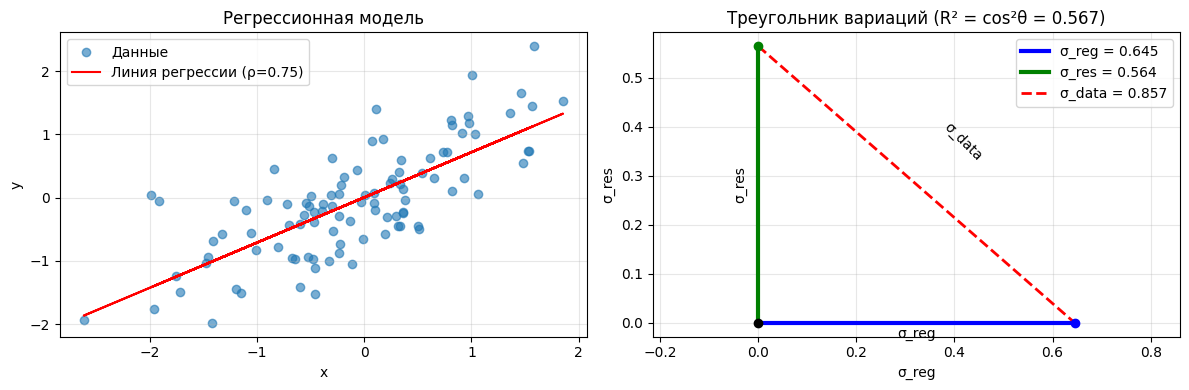

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Генерация данных с заданным коэффициентом корреляции
np.random.seed(42)
N = 100
x = np.random.normal(0, 1, N)
# y = rho * x + остаток с нужной дисперсией
rho_true = 0.8
sigma_res = np.sqrt(1 - rho_true**2)  # чтобы полная дисперсия y была 1
y = rho_true * x + sigma_res * np.random.normal(0, 1, N)

# Оценка параметров через linregress
slope, intercept, r, p_value, std_err = linregress(x, y)
R2 = r**2

# Предсказания модели
y_pred = intercept + slope * x

# Вычисление вариаций (смещённые оценки)
var_data = np.mean((y - np.mean(y))**2)
var_res = np.mean((y - y_pred)**2)
var_reg = np.mean((y_pred - np.mean(y))**2)

print(f"Коэффициент корреляции (ρ): {r:.4f}")
print(f"R² = ρ² = {R2:.4f}")
print(f"Var_data = {var_data:.4f}")
print(f"Var_res = {var_res:.4f}")
print(f"Var_reg = {var_reg:.4f}")
print(f"Var_res + Var_reg = {var_res+var_reg:.4f} (должно равняться Var_data)")

# График 1: данные и линия регрессии
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.scatter(x, y, alpha=0.6, label='Данные')
plt.plot(x, y_pred, 'r-', label=f'Линия регрессии (ρ={r:.2f})')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Регрессионная модель')
plt.legend()
plt.grid(alpha=0.3)

# График 2: треугольник стандартных отклонений
plt.subplot(1,2,2)
# Строим прямоугольный треугольник с катетами sigma_reg, sigma_res
sigma_data = np.sqrt(var_data)
sigma_reg = np.sqrt(var_reg)
sigma_res = np.sqrt(var_res)

# Координаты вершин: (0,0) - вершина прямого угла, (sigma_reg,0) и (0,sigma_res)
plt.plot([0, sigma_reg], [0, 0], 'b-', linewidth=3, label=f'σ_reg = {sigma_reg:.3f}')
plt.plot([0, 0], [0, sigma_res], 'g-', linewidth=3, label=f'σ_res = {sigma_res:.3f}')
plt.plot([0, sigma_reg], [sigma_res, 0], 'r--', linewidth=2, label=f'σ_data = {sigma_data:.3f}')
plt.scatter([sigma_reg], [0], color='blue', zorder=5)
plt.scatter([0], [sigma_res], color='green', zorder=5)
plt.scatter([0], [0], color='black', zorder=5)
plt.xlim(-0.1, sigma_data+0.1)
plt.ylim(-0.1, sigma_data+0.1)
plt.xlabel('σ_reg')
plt.ylabel('σ_res')
plt.title(f'Треугольник вариаций (R² = cos²θ = {R2:.3f})')
plt.text(sigma_reg/2, -0.03, 'σ_reg', ha='center')
plt.text(-0.05, sigma_res/2, 'σ_res', va='center', rotation=90)
plt.text(sigma_reg/2+0.05, sigma_res/2+0.05, 'σ_data', rotation=-45)
plt.grid(alpha=0.3)
plt.axis('equal')
plt.legend()
plt.tight_layout()
plt.show()

# Линейная регрессия через алгебру

К решению задачи мультилинейной регрессии можно прийти довольно естественно и с помощью линейной алгебры и геометрии, ведь даже то, что в функции потерь фигурирует норма вектора ошибок уже намекает, что у задачи есть геометрическая сторона. Мы видели, что попытка найти линейную модель, описывающую экспериментальные точки, приводит к уравнению
$ X \, \mathbf{w} \simeq \mathbf{y}. $

Если количество переменных равно количеству неизвестных и уравнения линейно независимы, то система имеет единственное решение. Однако, если число измерений превосходит число признаков, то есть уравнений больше чем неизвестных — система становится несовместной, переопределенной. В этом случае лучшее, что мы можем сделать — выбрать вектор $\mathbf{w}$, образ которого $X\mathbf{w}$ ближе остальных к $\mathbf{y}$. Напомню, что множество образов или колоночное пространство $\mathcal{C}(X)$ — это линейная комбинация вектор-столбцов матрицы $X$
$ \begin{pmatrix} | & | & & | \\ \mathbf{x}_0 & \mathbf{x}_1 & \cdots & \mathbf{x}_n \\ | & | & & | \end{pmatrix} \mathbf{w} = w_0 \mathbf{x}_0 + w_1 \mathbf{x}_1 + \cdots w_n \mathbf{x}_n . $

$\mathcal{C}(X)$ — $n+1$-мерное линейное подпространство (мы считаем фичи линейно независимыми), линейная оболочка вектор-столбцов $X$. Итак, если $\mathbf{y}$ принадлежит $\mathcal{C}(X)$, то мы можем найти решение, если нет — будем искать, так сказать, лучшее из нерешений.

Если в дополнение к векторам $\mathcal{C}(X)$ мы рассмотрим все вектора им перпендикулярные, то получим еще одно подпространство и сможем любой вектор из $\mathbb{R}^{N}$ разложить на две компоненты, каждая из которых живет в своем подпространстве. Второе, перпендикулярное пространство, можно характеризовать следующим образом (нам это понадобится в дальнейшем). Пускай $\mathbf{v} \in \mathbb{R}^{N}$, тогда
$ X^\top \mathbf{v} = \begin{pmatrix} - & \mathbf{x}_0^{\top} & - \\ \cdots & \cdots & \cdots\\ - & \mathbf{x}_n^{\top} & - \end{pmatrix} \mathbf{v} = \begin{pmatrix} \mathbf{x}_0^{\top} \cdot \mathbf{v} \\ \cdots \\ \mathbf{x}_n^{\top} \cdot \mathbf{v} \\ \end{pmatrix} $

равен нулю в том и только в том случае, если $\mathbf{v}$ перпендикулярен всем $\mathbf{x}_i$, а значит и целому $\mathcal{C}(X)$. Таким образом, мы нашли два перпендикулярных линейных подпространства, линейные комбинации векторов из которых полностью, без дыр, «покрывают» все $\mathbb{R}^N$. Иногда это обозначают c помощью символа ортогональной прямой суммы
$$\mathbb{R}^N = C(X) \oplus \ker(X^\top)$$



где $\text{ker}(X^{\top})=\{\mathbf{v}|X^{\top}\mathbf{v}=\mathbf{0}\}$, $\text{C}(X)$-образ X

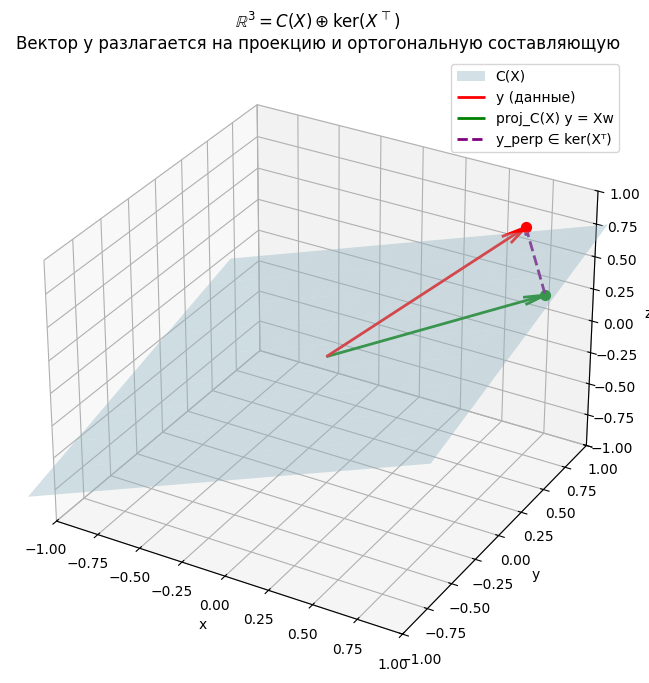

Скалярное произведение (y_proj, y_perp) = 1.84e-16


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Задаём колоночное пространство C(X) как плоскость, натянутую на два вектора
#    (в реальной регрессии это столбцы матрицы X)
u = np.array([1, 0.5, 0.2])
v = np.array([0, 1, 0.3])
# Нормируем, чтобы было красиво, но не обязательно
u = u / np.linalg.norm(u)
v = v / np.linalg.norm(v)

# Строим базис плоскости
C = np.column_stack([u, v])          # матрица 3x2

# 2. Выбираем произвольный вектор y
y = np.array([0.8, 0.6, 0.9])

# 3. Находим проекцию y на C(X) (решение МНК)
#    w = (X^T X)^{-1} X^T y, где X = C
w = np.linalg.lstsq(C, y, rcond=None)[0]   # веса w0, w1
y_proj = C @ w                               # прогнозируемое значение = X w
y_perp = y - y_proj                          # остаток (лежит в ker(X^T))

# 4. Настройка 3D-графика
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Рисуем плоскость C(X)
xx, yy = np.meshgrid(np.linspace(-1, 1, 10), np.linspace(-1, 1, 10))
# Параметрическое уравнение плоскости: a*u + b*v
grid_points = np.array([u*xx[i,j] + v*yy[i,j] for i in range(10) for j in range(10)])
X_plane = grid_points[:,0].reshape(10,10)
Y_plane = grid_points[:,1].reshape(10,10)
Z_plane = grid_points[:,2].reshape(10,10)
ax.plot_surface(X_plane, Y_plane, Z_plane, alpha=0.4, color='lightblue', label='C(X)')

# Вектор y (исходный)
ax.quiver(0, 0, 0, y[0], y[1], y[2], color='red', linewidth=2, arrow_length_ratio=0.1, label='y (данные)')
# Проекция y_proj
ax.quiver(0, 0, 0, y_proj[0], y_proj[1], y_proj[2], color='green', linewidth=2, arrow_length_ratio=0.1, label='proj_C(X) y = Xw')
# Перпендикулярная компонента (остаток) – рисуем от конца проекции к концу y
ax.quiver(y_proj[0], y_proj[1], y_proj[2], y_perp[0], y_perp[1], y_perp[2], 
          color='purple', linewidth=2, arrow_length_ratio=0.1, linestyle='dashed', label='y_perp ∈ ker(Xᵀ)')

# Отметим точку конца y и проекции
ax.scatter(*y, color='red', s=50)
ax.scatter(*y_proj, color='green', s=50)

# Настройка осей и легенды
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title(r'$\mathbb{R}^3 = C(X) \oplus \ker(X^\top)$' + '\n' + 'Вектор y разлагается на проекцию и ортогональную составляющую')
ax.legend()
plt.show()

# Проверка ортогональности: скалярное произведение проекции и остатка должно быть ~0
print(f"Скалярное произведение (y_proj, y_perp) = {np.dot(y_proj, y_perp):.2e}")